<a href="https://colab.research.google.com/github/Anshuman-kourav/Almabetter-Capstone-project/blob/main/gradient_descent_step_by_step.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.datasets import make_regression
import numpy as np

In [ ]:
X,y = make_regression(n_samples=4, n_features=1, n_informative=1, n_targets=1,noise=80,random_state=13)

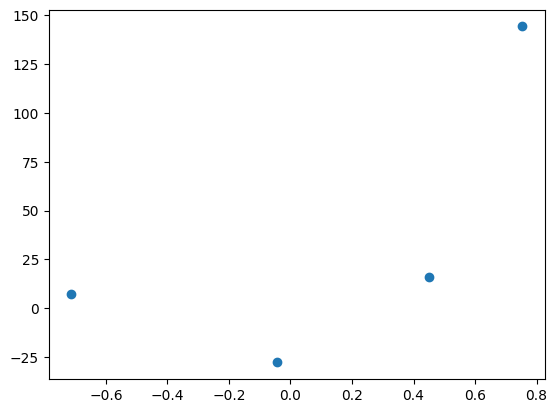

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(X,y)

In [ ]:
# Lets apply OLS
from sklearn.linear_model import LinearRegression

In [ ]:
reg = LinearRegression()
reg.fit(X,y)

LinearRegression()

In [ ]:
reg.coef_

array([78.35063668])

In [ ]:
reg.intercept_

26.15963284313262

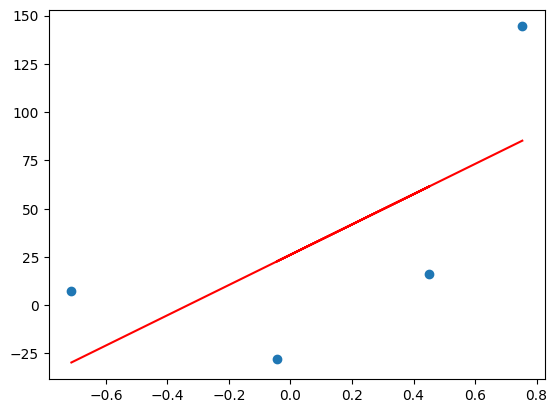

In [ ]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red')

In [ ]:
# Lets apply Gradient Descent assuming slope is constant m = 78.35
# and let's assume the starting value for intercept b = 0
# m and b ki value hai that's why i draw a line but i know is it not correct
# we calculate y values for this line
y_pred = ((78.35 * X) + 0).reshape(4)

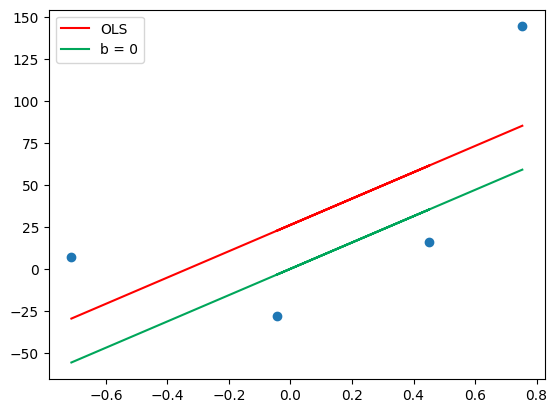

In [ ]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred,color='#00a65a',label='b = 0')
plt.legend()
plt.show()

# calculate slope for b=0

In [ ]:
m = 78.35
b = 0

loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope

-209.27763408209216

In [ ]:
# Lets take learning rate = 0.1
lr = 0.1

step_size = loss_slope*lr
step_size

-20.927763408209216

# new_b = old_b-step_size (n*slpoe)

In [ ]:
# Calculating the new intercept
b = b - step_size
b

20.927763408209216

# again we calculate y bcoz we want to plot a graph

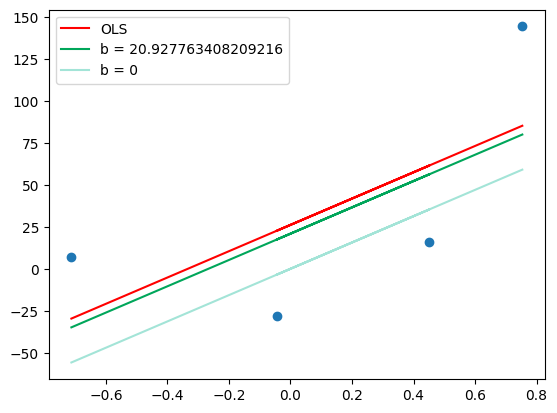

In [ ]:
y_pred1 = ((78.35 * X) + b).reshape(4)

plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred1,color='#00a65a',label='b = {}'.format(b))
plt.plot(X,y_pred,color='#A3E4D7',label='b = 0')
plt.legend()
plt.show()

In [ ]:
# Iteration 2
loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope

-41.85552681641843

In [ ]:
step_size = loss_slope*lr
step_size

-4.185552681641844

In [ ]:
b = b - step_size
b

25.11331608985106

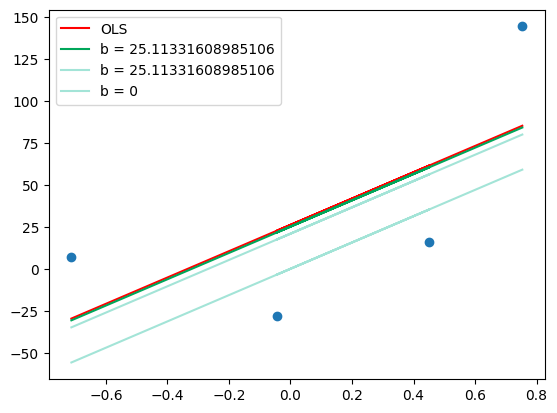

In [ ]:
y_pred2 = ((78.35 * X) + b).reshape(4)

plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred2,color='#00a65a',label='b = {}'.format(b))
plt.plot(X,y_pred1,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(X,y_pred,color='#A3E4D7',label='b = 0')
plt.legend()
plt.show()

In [ ]:
# Iteration 3
loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope

-8.371105363283675

In [ ]:
step_size = loss_slope*lr
step_size

-0.8371105363283675

In [ ]:
b = b - step_size
b

25.95042662617943

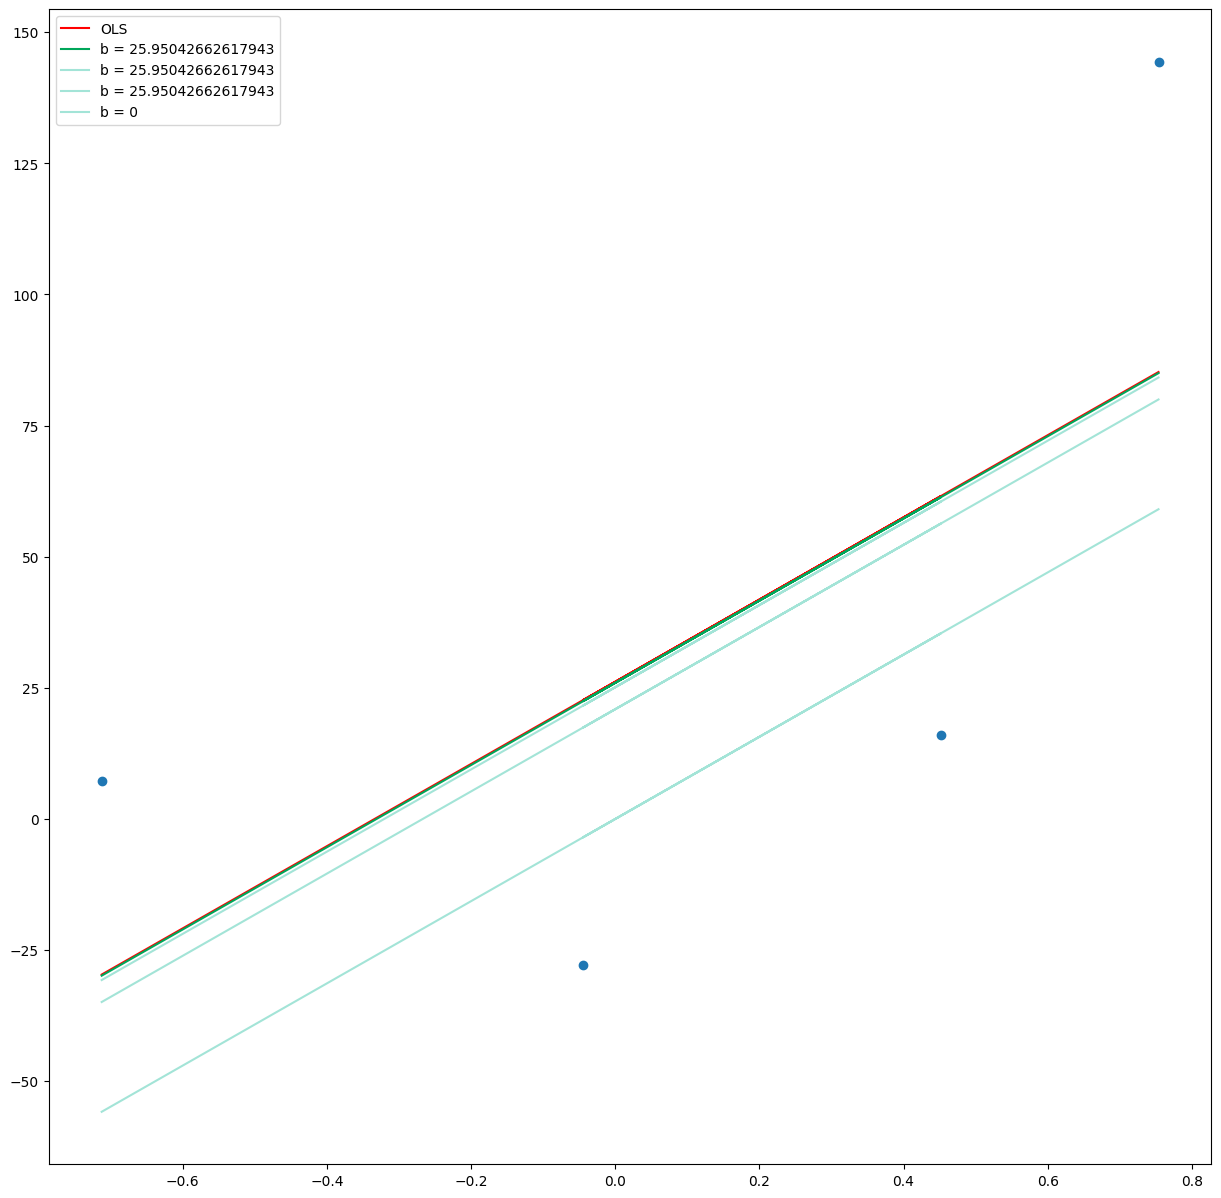

In [ ]:
y_pred3 = ((78.35 * X) + b).reshape(4)

plt.figure(figsize=(15,15))
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred3,color='#00a65a',label='b = {}'.format(b))
plt.plot(X,y_pred2,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(X,y_pred1,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(X,y_pred,color='#A3E4D7',label='b = 0')
plt.legend()
plt.show()

26.159237499043904


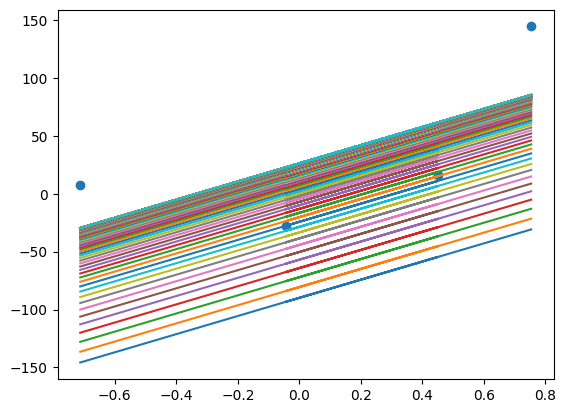

In [ ]:
b = -100
m = 78.35
lr = 0.01

epochs = 150

for i in range(epochs):
  loss_slope = -2 * np.sum(y - m*X.ravel() - b)
  b = b - (lr * loss_slope)

  y_pred = m * X + b


  plt.plot(X,y_pred)

plt.scatter(X,y)
print(b)

# only for seeing

35.86804475281324 -125.76832248787981


<ipython-input-62-1eea5d938083>:71: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(filename)


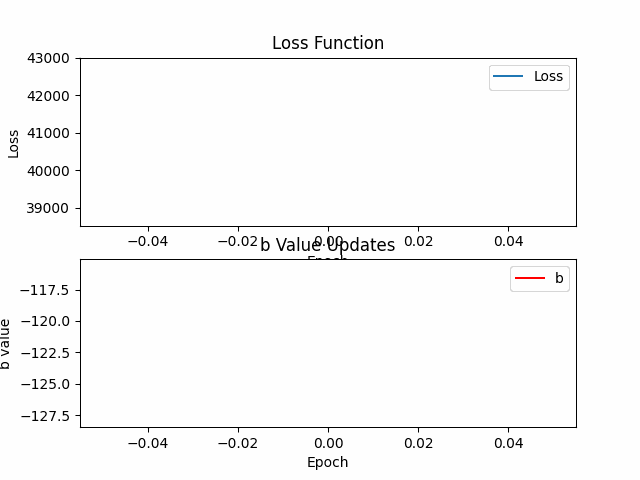

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import imageio

class GDRegressor:

    def __init__(self, learning_rate, epochs):
        self.m = 100
        self.b = -120
        self.lr = learning_rate
        self.epochs = epochs
        self.b_values = []
        self.loss_values = []

    def fit(self, X, y):
        # Calculate the b using GD
        for i in range(self.epochs):
            loss_slope_b = -2 * np.sum(y - self.m*X.ravel() - self.b)
            loss_slope_m = -2 * np.sum((y - self.m*X.ravel() - self.b)*X.ravel())

            self.b = self.b - (self.lr * loss_slope_b)
            self.m = self.m - (self.lr * loss_slope_m)

            # Store b and loss values
            self.b_values.append(self.b)
            loss = np.mean((y - (self.m * X + self.b)) ** 2)
            self.loss_values.append(loss)

        print(self.m, self.b)

    def predict(self, X):
        return self.m * X + self.b

# Assume X_train and y_train are already defined
X_train = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
y_train = np.array([1, 3, 2, 3, 5])

# Create and fit the model
gd = GDRegressor(0.001, 50)
gd.fit(X_train, y_train)

# Generate frames for the animation
filenames = []
for epoch in range(gd.epochs):
    plt.figure()

    # Plot the loss function
    plt.subplot(2, 1, 1)
    plt.plot(range(epoch+1), gd.loss_values[:epoch+1], label='Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss Function')
    plt.legend()

    # Plot the b values
    plt.subplot(2, 1, 2)
    plt.plot(range(epoch+1), gd.b_values[:epoch+1], label='b', color='red')
    plt.xlabel('Epoch')
    plt.ylabel('b value')
    plt.title('b Value Updates')
    plt.legend()

    filename = f'frame_{epoch}.png'
    plt.savefig(filename)
    filenames.append(filename)
    plt.close()

# Create the animated GIF
with imageio.get_writer('gradient_descent_animation.gif', mode='I', duration=0.5) as writer:
    for filename in filenames:
        image = imageio.imread(filename)
        writer.append_data(image)

# Clean up the frame files
import os
for filename in set(filenames):
    os.remove(filename)

# Display the animated GIF
from IPython.display import Image
Image(filename="gradient_descent_animation.gif")
